The code uses 3 github repositories :

- segment-geospatial

For basic SAM operations (automatic segmentation + point prompts)
- Grounded-Segment-Anything

For text-prompt-based segmentation (GroundingDINO → bounding boxes → SAM)
- Personalize-SAM

For one-shot personalized segmentation on LoveDA dataset

# Load dataset

Define Project + Dataset Paths

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/DLminorproject"
DATASET_DIR = f"{PROJECT_ROOT}/datasets"

TRAIN_URBAN = f"{DATASET_DIR}/Train/Urban"
TRAIN_RURAL = f"{DATASET_DIR}/Train/Rural"

VAL_URBAN = f"{DATASET_DIR}/Val/Urban"
VAL_RURAL = f"{DATASET_DIR}/Val/Rural"

TEST_URBAN = f"{DATASET_DIR}/Test/Urban"
TEST_RURAL = f"{DATASET_DIR}/Test/Rural"

Inspect One Folder Deeply

In [ ]:
print(os.listdir(TRAIN_URBAN)[:10])

['images_png', 'masks_png']


Define Inner LoveDA Paths

In [ ]:
TRAIN_URBAN_IMAGES = f"{TRAIN_URBAN}/images_png"
TRAIN_URBAN_MASKS = f"{TRAIN_URBAN}/masks_png"

First Sample Pair

In [ ]:
image_files = sorted(os.listdir(TRAIN_URBAN_IMAGES))
mask_files = sorted(os.listdir(TRAIN_URBAN_MASKS))

print("Total train urban images:", len(image_files))
print("Total train urban masks:", len(mask_files))

sample_image = image_files[0]
sample_mask = mask_files[0]

print("Sample image:", sample_image)
print("Sample mask:", sample_mask)

Total train urban images: 1156
Total train urban masks: 1157
Sample image: 1366.png
Sample mask: 1366.png


In [ ]:
sample_image_path = f"{TRAIN_URBAN_IMAGES}/{sample_image}"
sample_mask_path = f"{TRAIN_URBAN_MASKS}/{sample_mask}"

print(sample_image_path)
print(sample_mask_path)

/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1366.png
/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/masks_png/1366.png


Load Sample Image and Mask

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique mask values:", sorted(set(mask.flatten()))[:20])

Image shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Unique mask values: [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(5), np.uint8(6)]


Visualize Side by Side

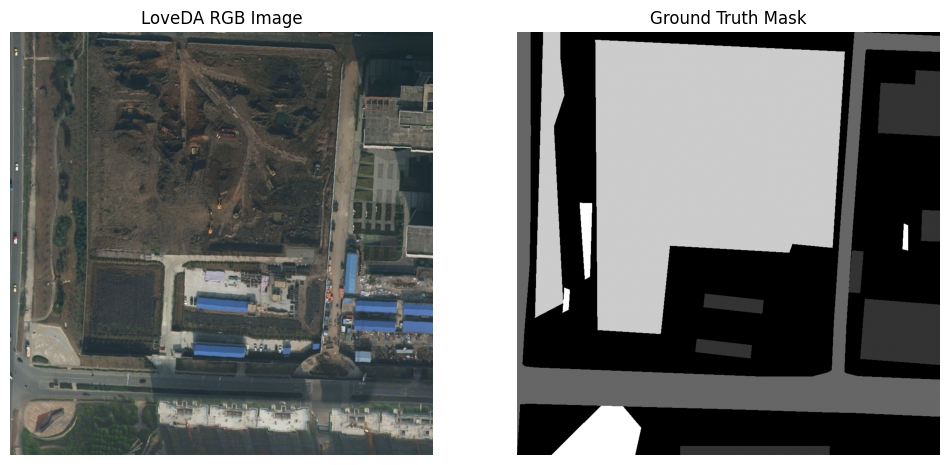

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("LoveDA RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

# Auto Segmentation (Phase 1)

Clone segment-geospatial

In [ ]:
%cd {PROJECT_ROOT}
!git clone https://github.com/opengeos/segment-geospatial.git

/content/drive/MyDrive/DLminorproject
fatal: destination path 'segment-geospatial' already exists and is not an empty directory.


Verify Clone

In [ ]:
print(os.path.exists(SEG_GEO))
print(os.listdir(SEG_GEO)[:10])

True
['sam_vit_h_4b8939.pth.20', 'sam_vit_h_4b8939.pth.9', 'sam_vit_h_4b8939.pth', 'sam_vit_h_4b8939.pth.5', 'sam_vit_h_4b8939.pth.23', 'sam_vit_h_4b8939.pth.13', 'sam_vit_h_4b8939.pth.12', 'sam_vit_h_4b8939.pth.7', 'sam_vit_h_4b8939.pth.22', 'sam_vit_h_4b8939.pth.3']


In [ ]:
import os

for item in os.listdir(SEG_GEO):
    print(item)

sam_vit_h_4b8939.pth.20
sam_vit_h_4b8939.pth.9
sam_vit_h_4b8939.pth
sam_vit_h_4b8939.pth.5
sam_vit_h_4b8939.pth.23
sam_vit_h_4b8939.pth.13
sam_vit_h_4b8939.pth.12
sam_vit_h_4b8939.pth.7
sam_vit_h_4b8939.pth.22
sam_vit_h_4b8939.pth.3
sam_vit_h_4b8939.pth.10
sam_vit_h_4b8939.pth.16
sam_vit_h_4b8939.pth.2
sam_vit_h_4b8939.pth.17
sam_vit_h_4b8939.pth.25
sam_vit_h_4b8939.pth.15
sam_vit_h_4b8939.pth.6
sam_vit_h_4b8939.pth.21
sam_vit_h_4b8939.pth.8
sam_vit_h_4b8939.pth.1
sam_vit_h_4b8939.pth.19
sam_vit_h_4b8939.pth.11
sam_vit_h_4b8939.pth.18
sam_vit_h_4b8939.pth.24
sam_vit_h_4b8939.pth.4
sam_vit_h_4b8939.pth.14
.git
.editorconfig
.github
.gitignore
.pre-commit-config.yaml
CITATION.cff
CODE_OF_CONDUCT.md
Dockerfile
LICENSE
MANIFEST.in
README.md
agent-harness
docs
mkdocs.yml
paper
pyproject.toml
qgis-samgeo-plugin
requirements.txt
requirements_dev.txt
requirements_docs.txt
samgeo
tests
segment_geospatial.egg-info
sam_vit_h_4b8939.pth.26


In [ ]:
main_pkg = os.path.join(SEG_GEO, "samgeo")
print(os.listdir(main_pkg))

['__init__.py', 'api.py', 'caption.py', 'common.py', 'detectree2.py', 'fast_sam.py', 'fer.py', 'hq_sam.py', 'samgeo.py', 'samgeo2.py', 'samgeo3.py', 'text_sam.py', 'utmconv.py', '__pycache__']


Install segment-geospatial in Editable Mode

In [ ]:
%cd /content/drive/MyDrive/DLminorproject/segment-geospatial
!pip install -e .

/content/drive/MyDrive/DLminorproject/segment-geospatial
Obtaining file:///content/drive/MyDrive/DLminorproject/segment-geospatial
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for segment-geospatial (pyproject.toml) ... done
  Created wheel for segment-geospatial: filename=segment_geospatial-1.3.2-0.editable-py2.py3-none-any.whl size=9331 sha256=228fd7acd425fd0c38cd16bcf16ba6accb5f2bbfe1457056229c5420b3a606af
  Stored in directory: /tmp/pip-ephem-wheel-cache-5zjordlt/wheels/ef/f6/8b/94e70984322e4cf9b20653a7c2a4a88241222d946bd3649b09
Successfully built segment-geospatial
  Attempting uninstall: segment-geospatial
    Found existing installation: segment-geospatial 1.3.2
    Uninstalling segment-geospatial-1.3.2:
      Successfully uninstalled segment-geospatial-1.3.2


Verify Installation

In [ ]:
%cd /content/drive/MyDrive/DLminorproject/segment-geospatial

/content/drive/MyDrive/DLminorproject/segment-geospatial


Install dependencies

In [ ]:
pip install -r requirements.txt

Import samgeo

In [ ]:
from samgeo import SamGeo
print("SamGeo imported successfully!")

SamGeo imported successfully!


Initialize SAM (Zero-Shot)

In [ ]:
sam = SamGeo(
    model_type="vit_h",   # highest accuracy
    automatic=True        # zero-shot mask generation
)

Load a Sample Image

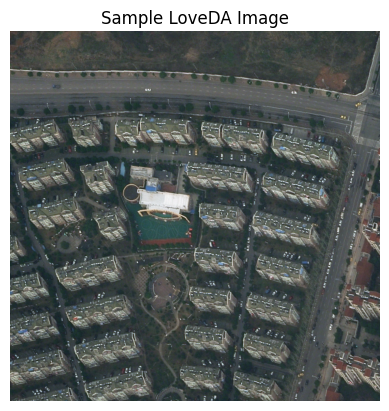

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"

image = Image.open(image_path)

plt.imshow(image)
plt.title("Sample LoveDA Image")
plt.axis("off")
plt.show()

In [ ]:
SUPPORT_IMG = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1531.png"
SUPPORT_MASK = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/masks_png/1531.png"

TEST_IMG = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"
TEST_MASK = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/masks_png/1653.png"

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

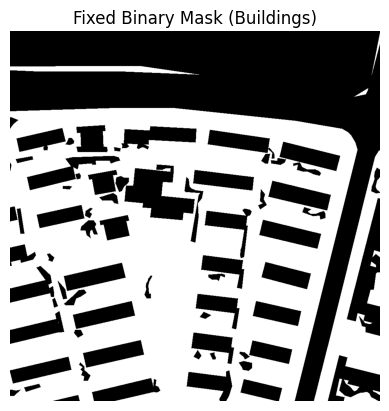

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

mask = np.array(Image.open(TEST_MASK))

# Extract building class ONLY
binary_mask = (mask == 1).astype(np.uint8) * 255

# Save
fixed_mask_path = "/content/drive/MyDrive/DLminorproject/test_mask_binary.png"
Image.fromarray(binary_mask).save(fixed_mask_path)

# Visualize
plt.imshow(binary_mask, cmap='gray')
plt.title("Fixed Binary Mask (Buildings)")
plt.axis('off')

Run Zero-Shot Segmentation

In [ ]:
sam.generate(
    image_path,
    output="/content/drive/MyDrive/DLminorproject/outputs/samgeo_mask.png"
)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


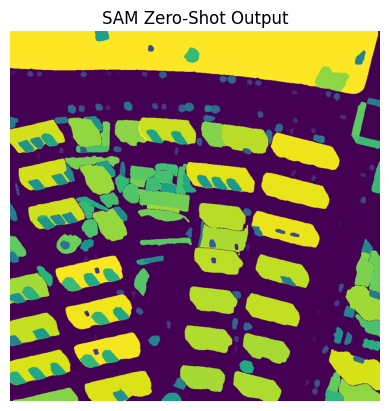

In [ ]:
import rasterio

mask_path = "/content/drive/MyDrive/DLminorproject/outputs/samgeo_mask.png"
with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.imshow(mask)
plt.title("SAM Zero-Shot Output")
plt.axis("off")
plt.show()

Visualize Predicted VS Ground Truth

Pred exists: True
GT exists: True


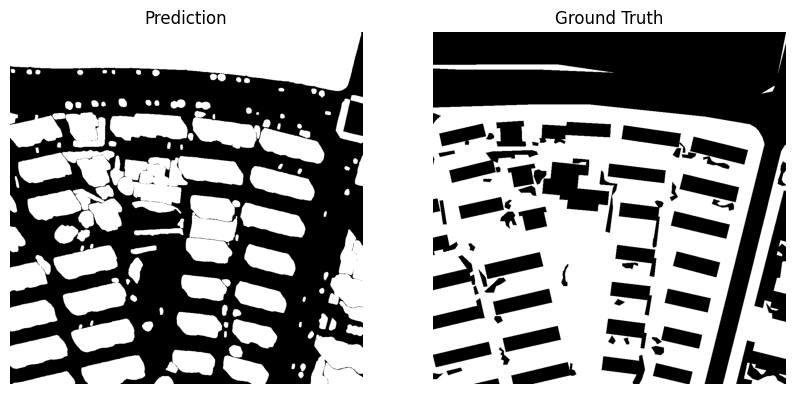

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Paths
pred_path = '/content/drive/MyDrive/DLminorproject/outputs/samgeo_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/persam_data/Annotations/building/01.png'

# Check paths
print("Pred exists:", os.path.exists(pred_path))
print("GT exists:", os.path.exists(gt_path))

# Load images
pred = cv2.imread(pred_path, 0)
gt   = cv2.imread(gt_path, 0)

# Safety check
if pred is None:
    print("Prediction image not loaded")
if gt is None:
    print("Ground truth image not loaded")

# Convert to binary
pred_bin = (pred > 0).astype('uint8')
gt_bin   = (gt > 0).astype('uint8')

# Resize if needed
if pred_bin.shape != gt_bin.shape:
    pred_bin = cv2.resize(
        pred_bin,
        (gt_bin.shape[1], gt_bin.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

Compute IOU

In [ ]:
import cv2
import numpy as np

def load_and_prepare_mask(path, is_pred=True):
    """
    Loads mask and converts to binary (0/1)
    """
    mask = cv2.imread(path, 0)  # grayscale
    mask = (mask > 0).astype(np.uint8)
    return mask


def compute_iou(pred, gt):
    """
    Computes IoU between two binary masks
    """
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union != 0 else 0


def evaluate_iou(pred_path, gt_path):
    """
    Full pipeline: load → resize → fix inversion → compute IoU
    """
    pred = load_and_prepare_mask(pred_path)
    gt = load_and_prepare_mask(gt_path)

    # Resize if needed
    if pred.shape != gt.shape:
        pred = cv2.resize(
            pred,
            (gt.shape[1], gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Compute both IoUs
    iou_normal = compute_iou(pred, gt)
    iou_inverted = compute_iou(1 - pred, gt)

    # Auto-fix inversion
    if iou_inverted > iou_normal:
        pred = 1 - pred
        final_iou = iou_inverted

    else:
        final_iou = iou_normal

    return final_iou


iou = evaluate_iou(pred_path, gt_path)
print("Auto Segmentation IoU:", iou)

Auto Segmentation IoU: 0.5153960100913499


# Muti-point segmentation (Phase 2)

In [ ]:
# Install core SAM dependencies (if not already)
!pip install segment-anything

LOAD SAM MODEL MANUALLY

In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import torch
import cv2
import matplotlib.pyplot as plt

LOAD MODEL WEIGHTS

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-04-22 06:44:37--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.33, 3.171.22.68, 3.171.22.118, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   135MB/s    in 20s     

2026-04-22 06:44:57 (122 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



INITIALIZE MODEL

In [ ]:
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device="cuda" if torch.cuda.is_available() else "cpu")

predictor = SamPredictor(sam)

In [ ]:
image = cv2.imread("/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

Perform multi-point segmentation

Total centroid points: 17


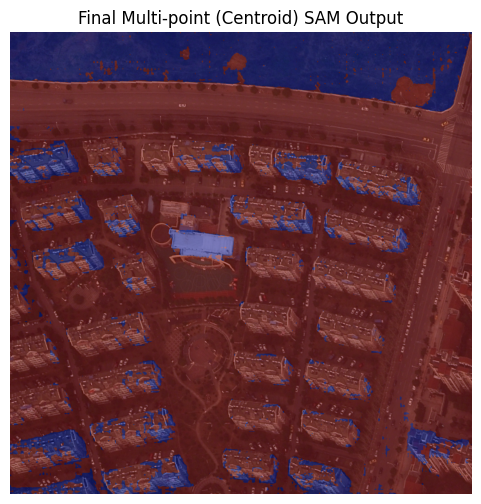

Saved at: /content/drive/MyDrive/DLminorproject/outputs/final_multipoint_mask.png


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load Image for SAM
img_path = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"
gt_path  = "/content/drive/MyDrive/DLminorproject/test_mask_binary.png"

image_source = np.array(Image.open(img_path))
predictor.set_image(image_source)


# 2. Generate Centroid Points (Foreground Only)

gt = cv2.imread(gt_path, 0)
gt_bin = (gt > 0).astype(np.uint8)

num_labels, labels = cv2.connectedComponents(gt_bin)

points = []
for label in range(1, num_labels):  # skip background
    ys, xs = np.where(labels == label)

    if len(xs) == 0:
        continue

    cx = int(np.mean(xs))
    cy = int(np.mean(ys))

    points.append([cx, cy])

input_point = np.array(points)
input_label = np.ones(len(input_point))

print("Total centroid points:", len(input_point))


# 3. SAM Prediction (Multi-point)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=False
)

point_mask = masks[0]


# 4. Visualization

plt.figure(figsize=(6,6))
plt.imshow(image_source)
plt.imshow(point_mask, alpha=0.5, cmap='jet')
plt.title("Final Multi-point (Centroid) SAM Output")
plt.axis('off')
plt.show()


# 5. Save Output

point_save = (point_mask.astype(np.uint8) * 255)

save_path = "/content/drive/MyDrive/DLminorproject/outputs/final_multipoint_mask.png"
Image.fromarray(point_save).save(save_path)

print("Saved at:", save_path)

Visualize Predicted VS Ground Truth

Pred exists: True
GT exists: True


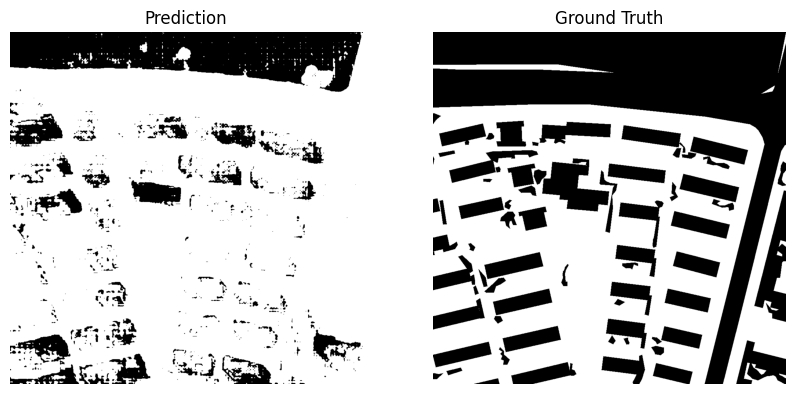

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Paths
pred_path = '/content/drive/MyDrive/DLminorproject/outputs/final_multipoint_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'

# Check paths
print("Pred exists:", os.path.exists(pred_path))
print("GT exists:", os.path.exists(gt_path))

# Load images
pred = cv2.imread(pred_path, 0)
gt   = cv2.imread(gt_path, 0)

# Safety check
if pred is None:
    print("Prediction image not loaded")
if gt is None:
    print("Ground truth image not loaded")

# Convert to binary
pred_bin = (pred > 0).astype('uint8')
gt_bin   = (gt > 0).astype('uint8')

# Resize if needed
if pred_bin.shape != gt_bin.shape:
    pred_bin = cv2.resize(
        pred_bin,
        (gt_bin.shape[1], gt_bin.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

In [ ]:
import cv2
import numpy as np

def load_and_prepare_mask(path, is_pred=True):
    """
    Loads mask and converts to binary (0/1)
    """
    mask = cv2.imread(path, 0)  # grayscale
    mask = (mask > 0).astype(np.uint8)
    return mask


def compute_iou(pred, gt):
    """
    Computes IoU between two binary masks
    """
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union != 0 else 0


def evaluate_iou(pred_path, gt_path):
    """
    Full pipeline: load → resize → fix inversion → compute IoU
    """
    pred = load_and_prepare_mask(pred_path)
    gt = load_and_prepare_mask(gt_path)

    # Resize if needed
    if pred.shape != gt.shape:
        pred = cv2.resize(
            pred,
            (gt.shape[1], gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Compute both IoUs
    iou_normal = compute_iou(pred, gt)
    iou_inverted = compute_iou(1 - pred, gt)

    # Auto-fix inversion
    if iou_inverted > iou_normal:
        pred = 1 - pred
        final_iou = iou_inverted
        print("Inversion detected → corrected")
    else:
        final_iou = iou_normal

    return final_iou

point_pred_path = '/content/drive/MyDrive/DLminorproject/outputs/final_multipoint_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'
iou = evaluate_iou(point_pred_path, gt_path)
print("Multi-point Segmentation IoU:", iou)

Multi-point Segmentation IoU: 0.5685297402975773


In [ ]:
%cd /content/drive/MyDrive/DLminorproject/Grounded-Segment-Anything

/content/drive/MyDrive/DLminorproject/Grounded-Segment-Anything


# Phase 3

Clone Grounded-segment-Anything


In [ ]:
!git clone https://github.com/IDEA-Research/Grounded-Segment-Anything.git
%cd Grounded-Segment-Anything

Install Stable Dependencies

In [ ]:
!pip install groundingdino-py
!pip install opencv-python matplotlib supervision

Patch Transformers Compatibility

In [ ]:
import torch
import transformers

# Patch 1: get_head_mask (you already had this)
if not hasattr(transformers.models.bert.modeling_bert.BertModel, "get_head_mask"):
    def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
        return [None] * num_hidden_layers
    transformers.models.bert.modeling_bert.BertModel.get_head_mask = get_head_mask


#  Patch 2: Fix dtype/device issue
from transformers.modeling_utils import PreTrainedModel

original_get_extended_attention_mask = PreTrainedModel.get_extended_attention_mask

def fixed_get_extended_attention_mask(self, attention_mask, input_shape, dtype=None):
    if isinstance(dtype, torch.device):
        dtype = torch.float32   # force correct dtype
    return original_get_extended_attention_mask(self, attention_mask, input_shape, dtype)

PreTrainedModel.get_extended_attention_mask = fixed_get_extended_attention_mask

print("All patches applied ")

All patches applied ✅


Download weights

In [ ]:
!wget -O /content/drive/MyDrive/DLminorproject/checkpoints/groundingdino_swint_ogc.pth \
https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth

--2026-04-22 07:44:48--  https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/611591640/f221e500-c2fc-4fd3-b84e-8ad92a6923f3?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-22T08%3A32%3A17Z&rscd=attachment%3B+filename%3Dgroundingdino_swint_ogc.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-22T07%3A31%3A26Z&ske=2026-04-22T08%3A32%3A17Z&sks=b&skv=2018-11-09&sig=az7c1G%2FV6qfT4T3sqGN4v7VDeLPiUCcNure7OlhfoWw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Njg0NzQ4OSwibmJmIjoxNzc2ODQzODg5LCJwYX

Import GroundingDINO

In [ ]:
from groundingdino.util.inference import load_model, load_image, predict

print("GroundingDINO ready")

GroundingDINO ready


Load Model

In [ ]:
CONFIG_PATH = "/content/drive/MyDrive/DLminorproject/Grounded-Segment-Anything/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"

WEIGHTS_PATH = "/content/drive/MyDrive/DLminorproject/checkpoints/groundingdino_swint_ogc.pth"

model = load_model(CONFIG_PATH, WEIGHTS_PATH)

final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Load image

In [ ]:
from groundingdino.util.inference import load_image

IMAGE_PATH = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"

image_source, image = load_image(IMAGE_PATH)

In [ ]:
from groundingdino.util.inference import predict

TEXT_PROMPT = "building"

boxes, logits, phrases = predict(
    model=model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=0.3,
    text_threshold=0.25,
    device="cpu"
)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


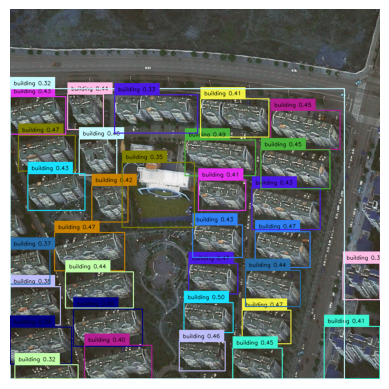

In [ ]:
from groundingdino.util.inference import annotate
import matplotlib.pyplot as plt

annotated_frame = annotate(
    image_source=image_source,
    boxes=boxes,
    logits=logits,
    phrases=phrases
)

plt.imshow(annotated_frame)
plt.axis("off")
plt.show()

In [ ]:

!wget -O /content/drive/MyDrive/DLminorproject/checkpoints/sam_vit_h_4b8939.pth \
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-04-22 07:48:40--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.13, 3.171.22.118, 3.171.22.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘/content/drive/MyDrive/DLminorproject/checkpoints/sam_vit_h_4b8939.pth’

/content/drive/MyDr 100%[===================>]   2.39G  31.3MB/s    in 90s     

2026-04-22 07:50:11 (27.1 MB/s) - ‘/content/drive/MyDrive/DLminorproject/checkpoints/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load SAM checkpoint
sam_checkpoint = "/content/drive/MyDrive/DLminorproject/checkpoints/sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to(device)

# Create predictor
predictor = SamPredictor(sam)

# Set image
predictor.set_image(image_source)

Using device: cpu


In [ ]:
import numpy as np
import torch

masks = []

H, W, _ = image_source.shape

for box, logit in zip(boxes, logits):

    # 🔥 KEEP ONLY STRONG BOXES
    if logit < 0.4:
        continue

    box = box.cpu().numpy()

    cx, cy, w, h = box

    scale = 1.0

    x1 = (cx - w/2) * W
    y1 = (cy - h/2) * H
    x2 = (cx + w/2) * W
    y2 = (cy + h/2) * H

    box_xyxy = np.array([x1, y1, x2, y2])

    transformed_box = predictor.transform.apply_boxes(
        np.array([box_xyxy]), (H, W)
    )

    mask, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=transformed_box[0],
        multimask_output=False
    )

    masks.append(mask[0])

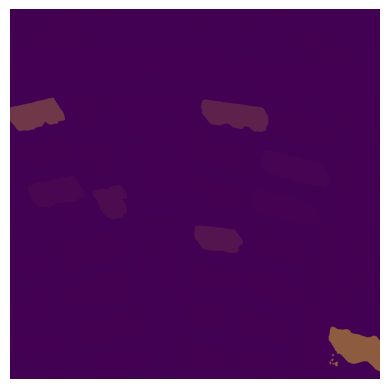

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image_source)

for mask in masks:
    plt.imshow(mask, alpha=0.4)

plt.axis("off")
plt.show()

In [ ]:
final_mask = np.zeros((H, W), dtype=np.uint8)

for mask in masks:
    final_mask = np.logical_or(final_mask, mask)

final_mask = final_mask.astype(np.uint8)

In [ ]:
save_path = "/content/drive/MyDrive/DLminorproject/outputs/pred_mask.png"

Image.fromarray(final_mask * 255).save(save_path)

print("Saved at:", save_path)

Saved at: /content/drive/MyDrive/DLminorproject/outputs/pred_mask.png


Visualize Predicted VS Ground Truth

Pred exists: True
GT exists: True


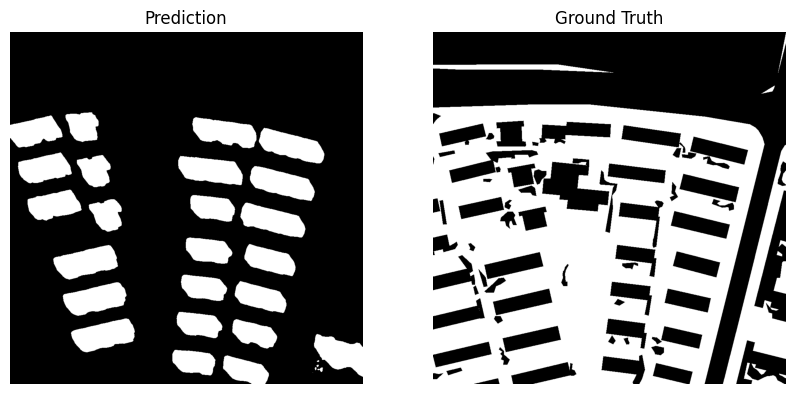

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Paths
pred_path = '/content/drive/MyDrive/DLminorproject/outputs/pred_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'

# Check paths
print("Pred exists:", os.path.exists(pred_path))
print("GT exists:", os.path.exists(gt_path))

# Load images
pred = cv2.imread(pred_path, 0)
gt   = cv2.imread(gt_path, 0)

# Safety check
if pred is None:
    print("Prediction image not loaded")
if gt is None:
    print("Ground truth image not loaded")

# Convert to binary
pred_bin = (pred > 0).astype('uint8')
gt_bin   = (gt > 0).astype('uint8')

# Resize if needed
if pred_bin.shape != gt_bin.shape:
    pred_bin = cv2.resize(
        pred_bin,
        (gt_bin.shape[1], gt_bin.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

In [ ]:
import cv2
import numpy as np

def load_and_prepare_mask(path, is_pred=True):
    """
    Loads mask and converts to binary (0/1)
    """
    mask = cv2.imread(path, 0)  # grayscale
    mask = (mask > 0).astype(np.uint8)
    return mask


def compute_iou(pred, gt):
    """
    Computes IoU between two binary masks
    """
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union != 0 else 0


def evaluate_iou(pred_path, gt_path):
    """
    Full pipeline: load → resize → fix inversion → compute IoU
    """
    pred = load_and_prepare_mask(pred_path)
    gt = load_and_prepare_mask(gt_path)

    # Resize if needed
    if pred.shape != gt.shape:
        pred = cv2.resize(
            pred,
            (gt.shape[1], gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Compute both IoUs
    iou_normal = compute_iou(pred, gt)
    iou_inverted = compute_iou(1 - pred, gt)

    # Auto-fix inversion
    if iou_inverted > iou_normal:
        pred = 1 - pred
        final_iou = iou_inverted
    else:
        final_iou = iou_normal

    return final_iou

box_pred_path = '/content/drive/MyDrive/DLminorproject/outputs/pred_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'
iou = evaluate_iou(box_pred_path, gt_path)
print("Text Prompt Segmentation IoU:", iou)

Text Prompt Segmentation IoU: 0.4891063305688345


Clone and enter Personalize-SAM properly

In [ ]:
%cd /content/drive/MyDrive/DLminorproject
!git clone https://github.com/ZrrSkywalker/Personalize-SAM.git

/content/drive/MyDrive/DLminorproject
fatal: destination path 'Personalize-SAM' already exists and is not an empty directory.


In [ ]:
%cd /content/drive/MyDrive/DLminorproject/Personalize-SAM

/content/drive/MyDrive/DLminorproject/Personalize-SAM


In [ ]:
!pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [ ]:
# !ls data/Images/cat
# !ls data/Annotations/cat

In [ ]:
#!python persam.py --data ./data --outdir cat_test

In [ ]:
# from PIL import Image
# import matplotlib.pyplot as plt

# img = Image.open("outputs/cat_test/cat/vis_mask_01.jpg")
# plt.imshow(img)
# plt.axis('off')

In [ ]:
SUPPORT_IMG = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1531.png"
SUPPORT_MASK = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/masks_png/1531.png"

TEST_IMG = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"
TEST_MASK = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/masks_png/1653.png"

In [ ]:
mask = np.array(Image.open(SUPPORT_MASK))
print(np.unique(mask))

[1 2 3 4 6]


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

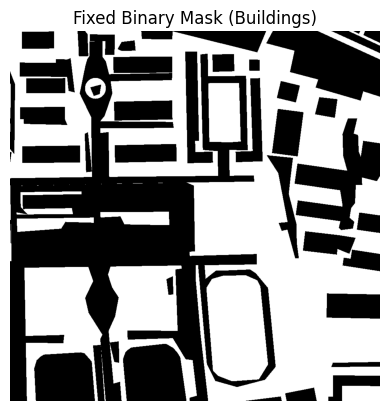

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

mask = np.array(Image.open(SUPPORT_MASK))

# Extract building class ONLY
binary_mask = (mask == 1).astype(np.uint8) * 255

# Save
fixed_mask_path = "/content/drive/MyDrive/DLminorproject/mask_binary.png"
Image.fromarray(binary_mask).save(fixed_mask_path)

# Visualize
plt.imshow(binary_mask, cmap='gray')
plt.title("Fixed Binary Mask (Buildings)")
plt.axis('off')

In [ ]:
import numpy as np
from PIL import Image

# Support
support_image = np.array(Image.open(SUPPORT_IMG).convert("RGB"))
support_mask = np.array(Image.open("/content/drive/MyDrive/DLminorproject/mask_binary.png").convert("L"))

# Test
test_image = np.array(Image.open(TEST_IMG).convert("RGB"))
gt_mask = np.array(Image.open(TEST_MASK).convert("L"))

print("Support Image:", support_image.shape)
print("Support Mask:", support_mask.shape)
print("Test Image:", test_image.shape)
print("GT Mask:", gt_mask.shape)

Support Image: (1024, 1024, 3)
Support Mask: (1024, 1024)
Test Image: (1024, 1024, 3)
GT Mask: (1024, 1024)


In [ ]:
%cd /content/drive/MyDrive/DLminorproject/Personalize-SAM
!ls

/content/drive/MyDrive/DLminorproject/Personalize-SAM
app.py	       outputs		      __pycache__
data	       persam_f_multi_obj.py  README.md
davis2017      persam_f.py	      requirements.txt
eval_miou.py   persam.py	      sam_vit_h_4b8939.pth
eval_video.py  persam_video_f.py      show.py
examples       persam_video.py	      weights
figs	       per_segment_anything
LICENSE.txt    prepare_coco.py


In [ ]:
!python persam_f.py \
  --data /content/drive/MyDrive/DLminorproject/persam_data \
  --outdir /content/drive/MyDrive/DLminorproject/outputs/persam_output \
  --ref_idx 00

Args: Namespace(data='/content/drive/MyDrive/DLminorproject/persam_data', outdir='/content/drive/MyDrive/DLminorproject/outputs/persam_output', ckpt='./sam_vit_h_4b8939.pth', sam_type='vit_h', lr=0.001, train_epoch=1000, log_epoch=200, ref_idx='00')

------------> Segment building
======> Load SAM
======> Obtain Self Location Prior
======> Start Training
Train Epoch: 0 / 1000
LR: 0.001000, Dice_Loss: 0.9877, Focal_Loss: 2.3804
Train Epoch: 200 / 1000
LR: 0.000904, Dice_Loss: 0.9813, Focal_Loss: 1.9796
Train Epoch: 400 / 1000
LR: 0.000653, Dice_Loss: 0.9385, Focal_Loss: 1.6709
Train Epoch: 600 / 1000
LR: 0.000344, Dice_Loss: 0.9251, Focal_Loss: 1.5169
Train Epoch: 800 / 1000
LR: 0.000095, Dice_Loss: 0.9208, Focal_Loss: 1.4569
======> Mask weights:
 [[-0.4583962 ]
 [ 0.63778543]
 [ 0.82061076]]
======> Start Testing
100% 2/2 [04:48<00:00, 144.49s/it]


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

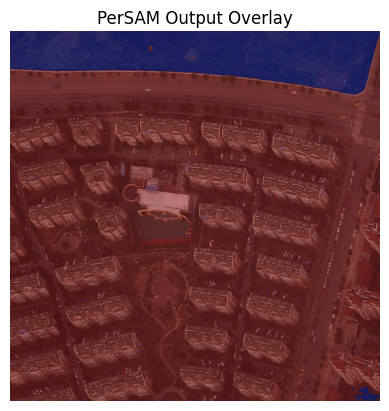

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DLminorproject/persam_data/Images/building/01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pred = cv2.imread('/content/drive/MyDrive/DLminorproject/outputs/persam_output/building/01.png')

# Convert mask to binary
pred = (pred[:,:,2] > 0).astype(np.uint8)   # use blue channel

plt.imshow(img)
plt.imshow(pred, alpha=0.5, cmap='jet')
plt.title("PerSAM Output Overlay")
plt.axis('off')

Visualize Predicted VS Ground Truth

Pred exists: True
GT exists: True


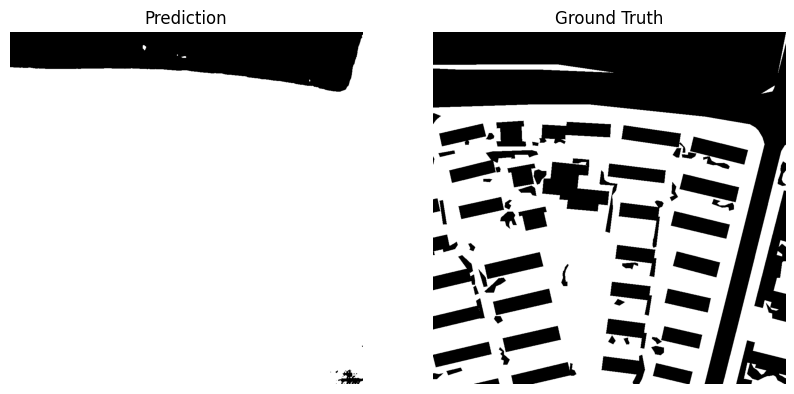

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Paths
pred_path = '/content/drive/MyDrive/DLminorproject/outputs/persam_output/building/01.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'

# Check paths
print("Pred exists:", os.path.exists(pred_path))
print("GT exists:", os.path.exists(gt_path))

# Load images
pred = cv2.imread(pred_path, 0)
gt   = cv2.imread(gt_path, 0)

# Safety check
if pred is None:
    print("Prediction image not loaded")
if gt is None:
    print("Ground truth image not loaded")

# Convert to binary
pred_bin = (pred > 0).astype('uint8')
gt_bin   = (gt > 0).astype('uint8')

# Resize if needed
if pred_bin.shape != gt_bin.shape:
    pred_bin = cv2.resize(
        pred_bin,
        (gt_bin.shape[1], gt_bin.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

In [ ]:

import cv2
import numpy as np

def load_and_prepare_mask(path, is_pred=True):
    """
    Loads mask and converts to binary (0/1)
    """
    mask = cv2.imread(path, 0)  # grayscale
    mask = (mask > 0).astype(np.uint8)
    return mask


def compute_iou(pred, gt):
    """
    Computes IoU between two binary masks
    """
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union != 0 else 0


def evaluate_iou(pred_path, gt_path):
    """
    Full pipeline: load → resize → fix inversion → compute IoU
    """
    pred = load_and_prepare_mask(pred_path)
    gt = load_and_prepare_mask(gt_path)

    # Resize if needed
    if pred.shape != gt.shape:
        pred = cv2.resize(
            pred,
            (gt.shape[1], gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Compute both IoUs
    iou_normal = compute_iou(pred, gt)
    iou_inverted = compute_iou(1 - pred, gt)

    # Auto-fix inversion
    if iou_inverted > iou_normal:
        pred = 1 - pred
        final_iou = iou_inverted
        print("Inversion detected → corrected")
    else:
        final_iou = iou_normal

    return final_iou

persam_pred_path = '/content/drive/MyDrive/DLminorproject/outputs/persam_output/building/01.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'
iou = evaluate_iou(persam_pred_path, gt_path)
print("One shot segmentation IoU:", iou)

One shot segmentation IoU: 0.585895502164217


# Phase 4 Modification

In [ ]:
import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt

Load image

In [ ]:
image_path = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"

image_source = cv2.imread(image_path)
image = cv2.cvtColor(image_source, cv2.COLOR_BGR2RGB)

In [ ]:
from groundingdino.util.inference import load_model, load_image, predict

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Load Weights

In [ ]:
CONFIG_PATH = "/content/drive/MyDrive/DLminorproject/Grounded-Segment-Anything/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"

WEIGHTS_PATH = "/content/drive/MyDrive/DLminorproject/checkpoints/groundingdino_swint_ogc.pth"

model = load_model(CONFIG_PATH, WEIGHTS_PATH)

final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
image_path = "/content/drive/MyDrive/DLminorproject/datasets/Train/Urban/images_png/1653.png"

image_source, image = load_image(image_path)

In [ ]:
boxes, logits, phrases = predict(
    model=model,
    image=image,
    caption="building",
    box_threshold=0.25,
    text_threshold=0.25,
    device="cpu"
)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [ ]:
h, w, _ = image_source.shape

boxes_xyxy = []

for box in boxes:
    cx, cy, bw, bh = box

    x1 = int((cx - bw/2) * w)
    y1 = int((cy - bh/2) * h)
    x2 = int((cx + bw/2) * w)
    y2 = int((cy + bh/2) * h)

    boxes_xyxy.append([x1, y1, x2, y2])

In [ ]:
filtered_boxes = []

for x1, y1, x2, y2 in boxes_xyxy:
    if (x2 - x1) > 40 and (y2 - y1) > 40:
        filtered_boxes.append([x1, y1, x2, y2])

boxes_xyxy = filtered_boxes

In [ ]:
def get_points_with_negatives(boxes, w, h):
    points = []
    labels = []

    for x1, y1, x2, y2 in boxes:
        # Positive point (center)
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2
        points.append([cx, cy])
        labels.append(1)

        # Box size
        bw = x2 - x1
        bh = y2 - y1

        # Negative points (far outside)
        nx1 = x1 - bw//2
        ny1 = y1 - bh//2
        nx2 = x2 + bw//2
        ny2 = y2 + bh//2

        nx1 = max(0, min(nx1, w-1))
        ny1 = max(0, min(ny1, h-1))
        nx2 = max(0, min(nx2, w-1))
        ny2 = max(0, min(ny2, h-1))

        points.append([nx1, ny1])
        labels.append(0)

        points.append([nx2, ny2])
        labels.append(0)

    return np.array(points), np.array(labels)

h, w, _ = image_source.shape
input_points, input_labels = get_points_with_negatives(boxes_xyxy, w, h)

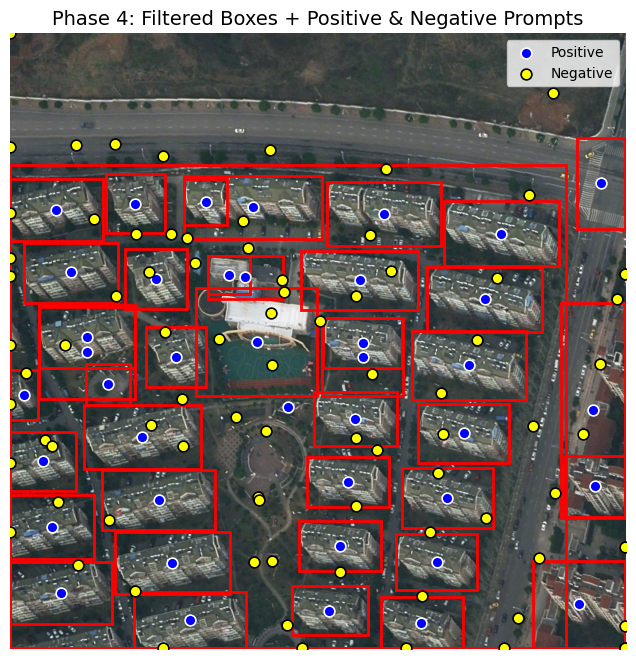

In [ ]:
# plt.figure(figsize=(8, 8))
# plt.imshow(image_source)

# Draw bounding boxes
for x1, y1, x2, y2 in boxes_xyxy:
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            edgecolor='red',
            facecolor='none',
            linewidth=2
        )
    )

# Draw points (positive & negative)
for (x, y), label in zip(input_points, input_labels):
    if label == 1:
        # Positive → Blue with white border
        plt.scatter(
            x, y,
            c='blue',
            s=60,
            edgecolors='white',
            linewidth=1.2,
            label='Positive'  # will handle legend below
        )
    else:
        # Negative → Yellow with black border
        plt.scatter(
            x, y,
            c='yellow',
            s=60,
            edgecolors='black',
            linewidth=1.2,
            label='Negative'
        )

# Fix duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# Set proper image limits (important)
plt.xlim(0, image_source.shape[1])
plt.ylim(image_source.shape[0], 0)

# Title & formatting
plt.title("Phase 4: Filtered Boxes + Positive & Negative Prompts", fontsize=14)
plt.axis('off')

plt.show()

In [ ]:
predictor.set_image(image_source)

masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=False
)

mask = masks[0]

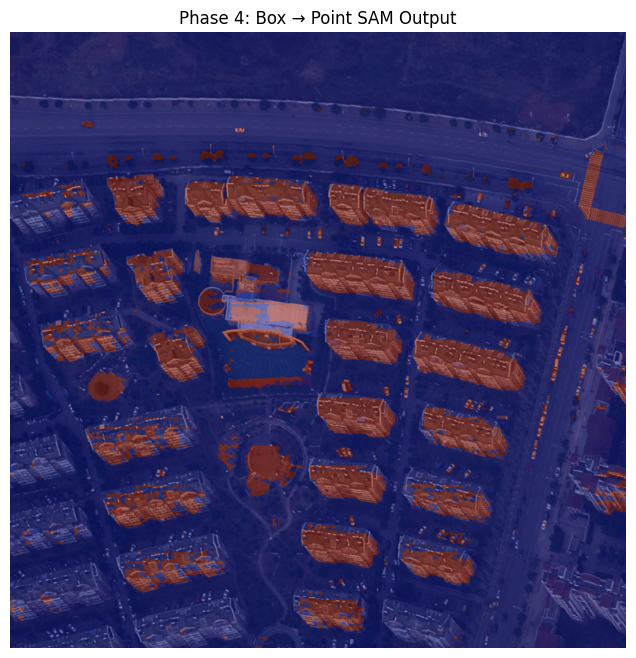

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image_source)
plt.imshow(mask, alpha=0.5, cmap='jet')

plt.title("Phase 4: Box → Point SAM Output")
plt.axis('off')
plt.show()

In [ ]:
mask_uint8 = (mask * 255).astype(np.uint8)

Refining Generated mask

In [ ]:
kernel = np.ones((7,7), np.uint8)

# Remove small false positives
mask_clean = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)

# Fill small holes inside buildings
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

In [ ]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_clean, connectivity=8)

min_area = 500

final_mask = np.zeros_like(mask_clean)

for i in range(1, num_labels):  # skip background
    area = stats[i, cv2.CC_STAT_AREA]

    if area > min_area:
        final_mask[labels == i] = 255

In [ ]:
pred = (final_mask > 0).astype(np.uint8)

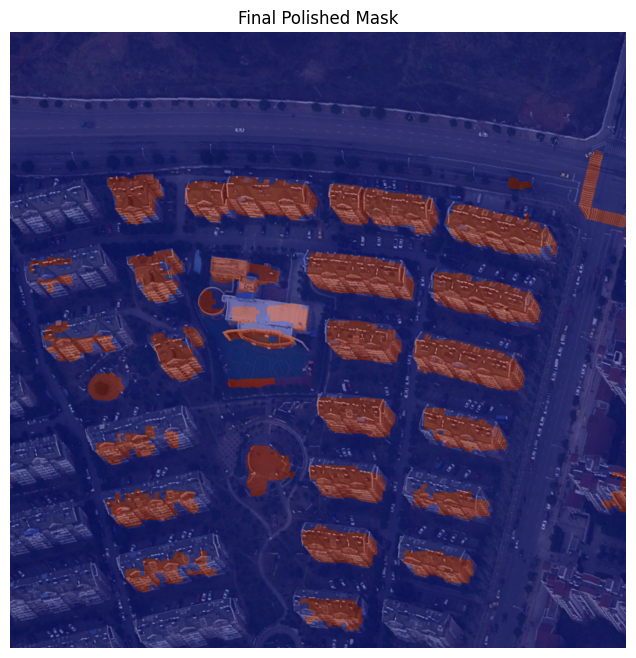

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image_source)
plt.imshow(final_mask, alpha=0.5, cmap='jet')

plt.title("Final Polished Mask")
plt.axis('off')
plt.show()

In [ ]:
output_path = "/content/drive/MyDrive/DLminorproject/outputs/phase4_final_mask.png"

cv2.imwrite(output_path, final_mask)

True

Pred exists: True
GT exists: True


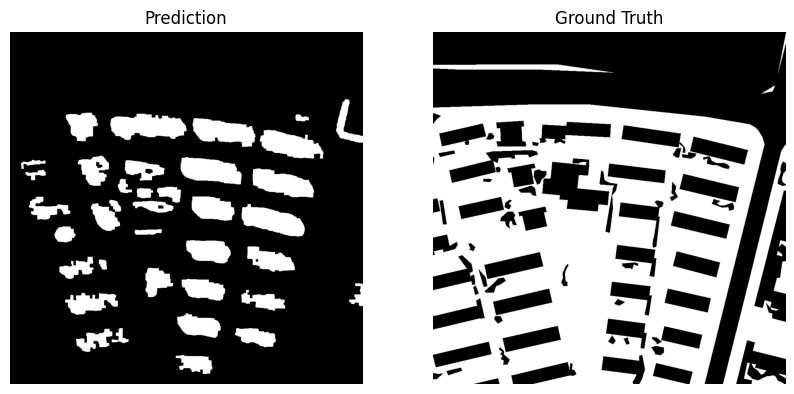

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Paths
pred_path = '/content/drive/MyDrive/DLminorproject/outputs/phase4_final_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'

# Check paths
print("Pred exists:", os.path.exists(pred_path))
print("GT exists:", os.path.exists(gt_path))

# Load images
pred = cv2.imread(pred_path, 0)
gt   = cv2.imread(gt_path, 0)

# Safety check
if pred is None:
    print("Prediction image not loaded")
if gt is None:
    print("Ground truth image not loaded")

# Convert to binary
pred_bin = (pred > 0).astype('uint8')
gt_bin   = (gt > 0).astype('uint8')

# Resize if needed
if pred_bin.shape != gt_bin.shape:
    pred_bin = cv2.resize(
        pred_bin,
        (gt_bin.shape[1], gt_bin.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# Plot side-by-side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pred_bin, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

# gt_corrected = 1 - gt
# diff = pred ^ gt_corrected
# plt.imshow(diff, cmap='gray')

In [ ]:

import cv2
import numpy as np

def load_and_prepare_mask(path, is_pred=True):
    """
    Loads mask and converts to binary (0/1)
    """
    mask = cv2.imread(path, 0)  # grayscale
    mask = (mask > 0).astype(np.uint8)
    return mask


def compute_iou(pred, gt):
    """
    Computes IoU between two binary masks
    """
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union != 0 else 0


def evaluate_iou(pred_path, gt_path):
    """
    Full pipeline: load → resize → fix inversion → compute IoU
    """
    pred = load_and_prepare_mask(pred_path)
    gt = load_and_prepare_mask(gt_path)

    # Resize if needed
    if pred.shape != gt.shape:
        pred = cv2.resize(
            pred,
            (gt.shape[1], gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Compute both IoUs
    iou_normal = compute_iou(pred, gt)
    iou_inverted = compute_iou(1 - pred, gt)

    # Auto-fix inversion
    if iou_inverted > iou_normal:
        pred = 1 - pred
        final_iou = iou_inverted

    else:
        final_iou = iou_normal

    return final_iou

persam_pred_path = '/content/drive/MyDrive/DLminorproject/outputs/phase4_final_mask.png'
gt_path   = '/content/drive/MyDrive/DLminorproject/test_mask_binary.png'
iou = evaluate_iou(persam_pred_path, gt_path)
print("Bounding Box Center Prompting IoU:", iou)

Bounding Box Center Prompting IoU: 0.5215401307742418
